## Exercise 1

**Dataset Used:** Synthetic Classification Data (sklearn.datasets)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

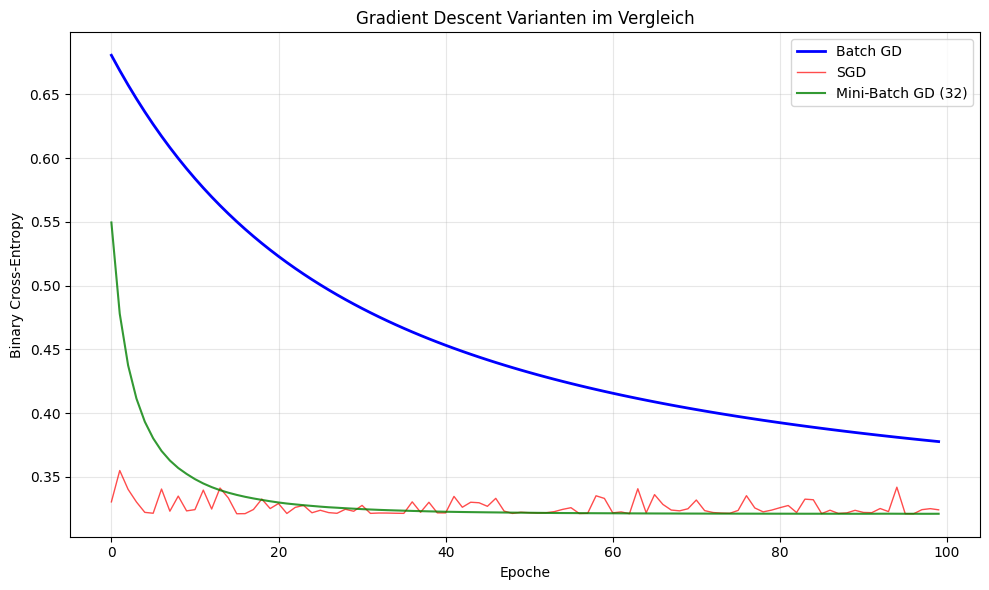

Finale Verluste — Batch: 0.3777 | SGD: 0.3242 | Mini-Batch: 0.3211


In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 2: Das Perzeptron
# Niveau: Experten
# Aufgabe 1 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Compare Stochastic, Mini-Batch, and Batch Gradient Descent
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, 
                            n_clusters_per_class=1, random_state=42)
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = y.astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def verlust(X, y, w, b):
    """Binary Cross-Entropy Verlust"""
    pred = sigmoid(X @ w + b)
    pred = np.clip(pred, 1e-15, 1-1e-15)
    return -np.mean(y * np.log(pred) + (1-y) * np.log(1-pred))

def trainieren(X, y, modus='sgd', lernrate=0.1, epochen=100, batch_groesse=32):
    """Trainiert mit gewähltem Gradienten-Abstieg-Modus"""
    w = np.zeros(X.shape[1]); b = 0.0; kosten = []
    for epoche in range(epochen):
        if modus == 'batch':
            # Vollständiger Batch
            pred = sigmoid(X @ w + b)
            grad_w = X.T @ (pred - y) / len(X)
            grad_b = (pred - y).mean()
            w -= lernrate * grad_w; b -= lernrate * grad_b
        elif modus == 'sgd':
            # Stochastisch: ein Datenpunkt pro Update
            idx = np.random.permutation(len(X))
            for i in idx:
                pred = sigmoid(np.dot(X[i], w) + b)
                fehler = pred - y[i]
                w -= lernrate * fehler * X[i]; b -= lernrate * fehler
        elif modus == 'mini-batch':
            # Mini-Batch: kleine Teilmengen
            idx = np.random.permutation(len(X))
            for start in range(0, len(X), batch_groesse):
                batch = idx[start:start+batch_groesse]
                Xb, yb = X[batch], y[batch]
                pred = sigmoid(Xb @ w + b)
                w -= lernrate * Xb.T @ (pred - yb) / len(batch)
                b -= lernrate * (pred - yb).mean()
        kosten.append(verlust(X, y, w, b))
    return kosten

np.random.seed(42)
kosten_batch = trainieren(X, y, 'batch')
kosten_sgd   = trainieren(X, y, 'sgd')
kosten_mini  = trainieren(X, y, 'mini-batch')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(kosten_batch, 'b-', linewidth=2, label='Batch GD')
ax.plot(kosten_sgd,   'r-', linewidth=1, alpha=0.7, label='SGD')
ax.plot(kosten_mini,  'g-', linewidth=1.5, alpha=0.8, label='Mini-Batch GD (32)')
ax.set_xlabel('Epoche'); ax.set_ylabel('Binary Cross-Entropy')
ax.set_title('Gradient Descent Varianten im Vergleich')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gradient_descent_vergleich.png', dpi=100)
plt.show()
print(f"Finale Verluste — Batch: {kosten_batch[-1]:.4f} | SGD: {kosten_sgd[-1]:.4f} | Mini-Batch: {kosten_mini[-1]:.4f}")


## Exercise 2

**Dataset Used:** Custom/Synthetic Array Data (numpy)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

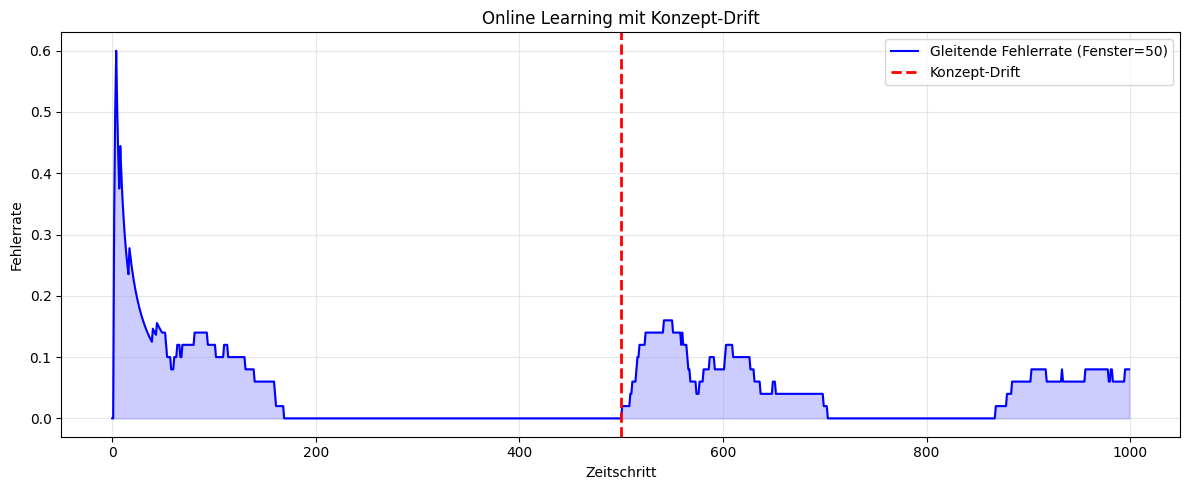

Fehlerrate vor Drift (t<500):  1.34%
Fehlerrate nach Drift (t>500): 7.97%


In [2]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 2: Das Perzeptron
# Niveau: Experten
# Aufgabe 2 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Simulate online learning and concept drift detection
import numpy as np
import matplotlib

import matplotlib.pyplot as plt

np.random.seed(42)
n_gesamt = 1000

# Datenstrom mit Konzept-Drift bei t=500
t = np.arange(n_gesamt)
X = np.random.randn(n_gesamt, 2)
# Konzept 1 (t<500): Entscheidung basiert auf x0 + x1 > 0
# Konzept 2 (t>=500): Entscheidung basiert auf x0 - x1 > 0 (Drift!)
y = np.where(t < 500, 
             (X[:,0] + X[:,1] > 0).astype(int),
             (X[:,0] - X[:,1] > 0).astype(int))

class OnlinePerzeptron:
    """Perzeptron mit Online-Lernregel für Datenstrom"""
    def __init__(self, lernrate=0.01):
        self.w = np.zeros(2); self.b = 0.0; self.lr = lernrate
    def aktualisieren(self, x, y):
        pred = 1 if (np.dot(x, self.w) + self.b) >= 0 else 0
        fehler = y - pred
        self.w += self.lr * fehler * x
        self.b += self.lr * fehler
        return int(pred != y)

modell = OnlinePerzeptron(lernrate=0.1)
fenster = 50
fehlerraten = []
aktuelles_fenster = []

# Datenstrom verarbeiten
for i in range(n_gesamt):
    ist_fehler = modell.aktualisieren(X[i], y[i])
    aktuelles_fenster.append(ist_fehler)
    if len(aktuelles_fenster) > fenster:
        aktuelles_fenster.pop(0)
    fehlerraten.append(np.mean(aktuelles_fenster))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t, fehlerraten, 'b-', linewidth=1.5, label='Gleitende Fehlerrate (Fenster=50)')
ax.axvline(x=500, color='red', linestyle='--', linewidth=2, label='Konzept-Drift')
ax.fill_between(t, fehlerraten, alpha=0.2, color='blue')
ax.set_xlabel('Zeitschritt'); ax.set_ylabel('Fehlerrate')
ax.set_title('Online Learning mit Konzept-Drift')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('konzept_drift.png', dpi=100)
plt.show()
print(f"Fehlerrate vor Drift (t<500):  {np.mean(fehlerraten[100:500]):.2%}")
print(f"Fehlerrate nach Drift (t>500): {np.mean(fehlerraten[500:700]):.2%}")


## Exercise 3

**Dataset Used:** Custom/Synthetic Array Data (numpy)

The following code implements the steps for this exercise. Outputs and charts are generated automatically inline.

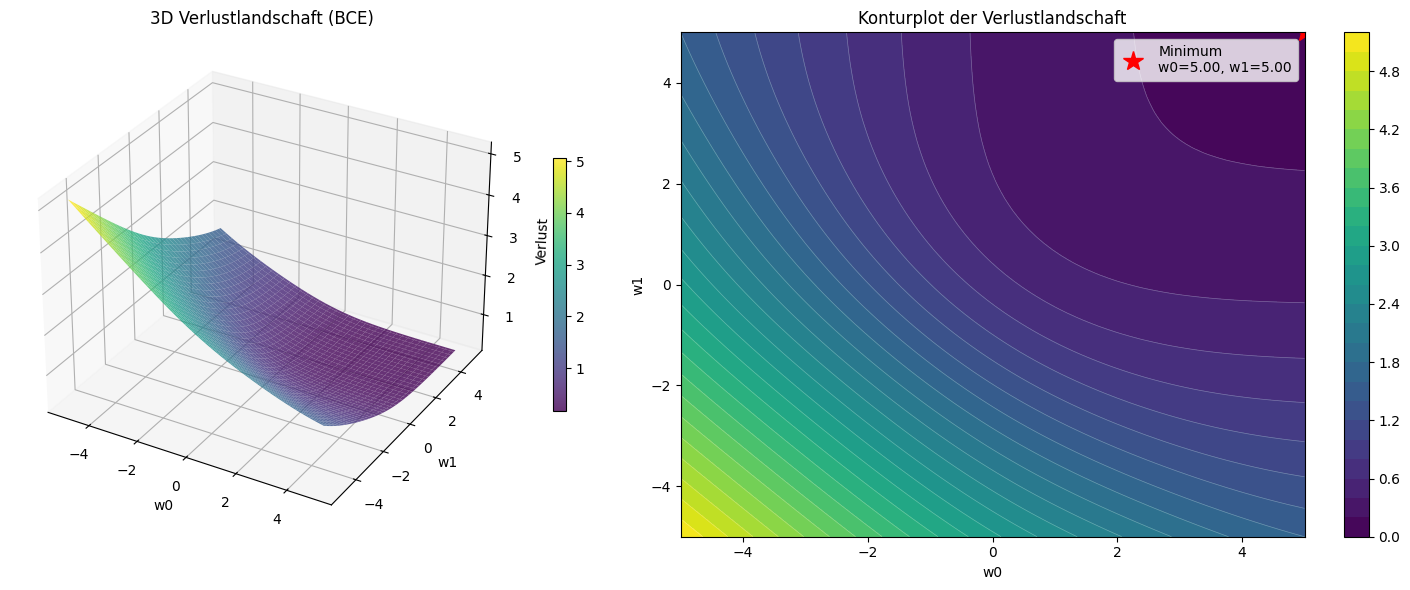

Minimum bei: w0=5.000, w1=5.000, Verlust=0.1767


In [3]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 2: Das Perzeptron
# Niveau: Experten
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Visualize the loss landscape for a 2-parameter perceptron
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)
X = np.array([[0,1],[1,0],[1,1],[0,0]], dtype=float)
y = np.array([1, 1, 1, 0], dtype=float)  # OR

def verlust_landschaft(w0, w1, b=0.0):
    """Binary Cross-Entropy für 2D-Gewichtsraum"""
    verlust = 0
    for xi, yi in zip(X, y):
        z = w0*xi[0] + w1*xi[1] + b
        pred = 1 / (1 + np.exp(-np.clip(z, -500, 500)))
        pred = np.clip(pred, 1e-15, 1-1e-15)
        verlust += -(yi*np.log(pred) + (1-yi)*np.log(1-pred))
    return verlust / len(X)

# Verlustlandschaft berechnen
w0_vals = np.linspace(-5, 5, 80)
w1_vals = np.linspace(-5, 5, 80)
W0, W1 = np.meshgrid(w0_vals, w1_vals)
V = np.vectorize(verlust_landschaft)(W0, W1)

fig = plt.figure(figsize=(16, 6))

# 3D Oberfläche
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(W0, W1, V, cmap='viridis', alpha=0.8)
ax1.set_xlabel('w0'); ax1.set_ylabel('w1'); ax1.set_zlabel('Verlust')
ax1.set_title('3D Verlustlandschaft (BCE)')
fig.colorbar(surf, ax=ax1, shrink=0.5)

# Konturplot
ax2 = fig.add_subplot(122)
kontur = ax2.contourf(W0, W1, V, levels=30, cmap='viridis')
ax2.contour(W0, W1, V, levels=30, colors='white', alpha=0.3, linewidths=0.5)
ax2.set_xlabel('w0'); ax2.set_ylabel('w1')
ax2.set_title('Konturplot der Verlustlandschaft')
fig.colorbar(kontur, ax=ax2)

# Minimum markieren
min_idx = np.unravel_index(V.argmin(), V.shape)
ax2.plot(W0[min_idx], W1[min_idx], 'r*', markersize=15,
         label=f'Minimum\nw0={W0[min_idx]:.2f}, w1={W1[min_idx]:.2f}')
ax2.legend()

plt.tight_layout()
plt.savefig('verlustlandschaft.png', dpi=100)
plt.show()
print(f"Minimum bei: w0={W0[min_idx]:.3f}, w1={W1[min_idx]:.3f}, Verlust={V[min_idx]:.4f}")
